<a href="https://colab.research.google.com/github/Rijeesha206/RIJI/blob/main/concrete_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn import metrics

In [ ]:
from google.colab import files
files.upload()

Saving Concrete_Data_Yeh.csv to Concrete_Data_Yeh (1).csv


{'Concrete_Data_Yeh.csv': b'cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa\r\n540,0,0,162,2.5,1040,676,28,79.99\r\n540,0,0,162,2.5,1055,676,28,61.89\r\n332.5,142.5,0,228,0,932,594,270,40.27\r\n332.5,142.5,0,228,0,932,594,365,41.05\r\n198.6,132.4,0,192,0,978.4,825.5,360,44.3\r\n266,114,0,228,0,932,670,90,47.03\r\n380,95,0,228,0,932,594,365,43.7\r\n380,95,0,228,0,932,594,28,36.45\r\n266,114,0,228,0,932,670,28,45.85\r\n475,0,0,228,0,932,594,28,39.29\r\n198.6,132.4,0,192,0,978.4,825.5,90,38.07\r\n198.6,132.4,0,192,0,978.4,825.5,28,28.02\r\n427.5,47.5,0,228,0,932,594,270,43.01\r\n190,190,0,228,0,932,670,90,42.33\r\n304,76,0,228,0,932,670,28,47.81\r\n380,0,0,228,0,932,670,90,52.91\r\n139.6,209.4,0,192,0,1047,806.9,90,39.36\r\n342,38,0,228,0,932,670,365,56.14\r\n380,95,0,228,0,932,594,90,40.56\r\n475,0,0,228,0,932,594,180,42.62\r\n427.5,47.5,0,228,0,932,594,180,41.84\r\n139.6,209.4,0,192,0,1047,806.9,28,28.24\r\n139.6,209.4,0,192,0,1047,806.9,3,8.06\r\n139.6

In [ ]:
cement_data=pd.read_csv('Concrete_Data_Yeh.csv')
cement_data

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [ ]:
cement_data.isnull().sum()

cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
csMPa               0
dtype: int64

In [ ]:
cement_data.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [ ]:
cement_data.tail()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77
1029,260.9,100.5,78.3,200.6,8.6,864.5,761.5,28,32.40


In [ ]:
cement_data.describe()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [ ]:
cement_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            1030 non-null   float64
 1   slag              1030 non-null   float64
 2   flyash            1030 non-null   float64
 3   water             1030 non-null   float64
 4   superplasticizer  1030 non-null   float64
 5   coarseaggregate   1030 non-null   float64
 6   fineaggregate     1030 non-null   float64
 7   age               1030 non-null   int64  
 8   csMPa             1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [ ]:
cement_data.shape

(1030, 9)

In [ ]:
correlation=cement_data.corr

<Axes: >

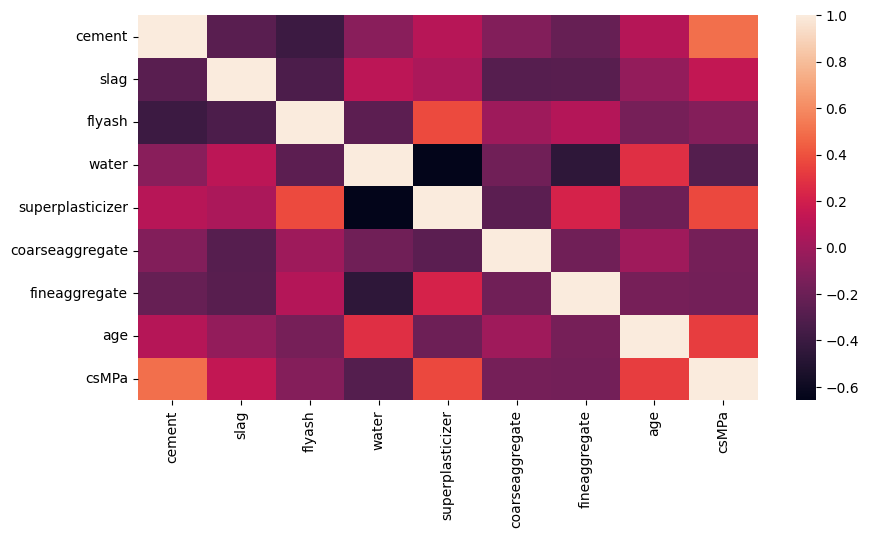

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(cement_data.corr())


<ipython-input-51-787a20964a80>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(cement_data['csMPa'],color='blue')


<Axes: xlabel='csMPa', ylabel='Density'>

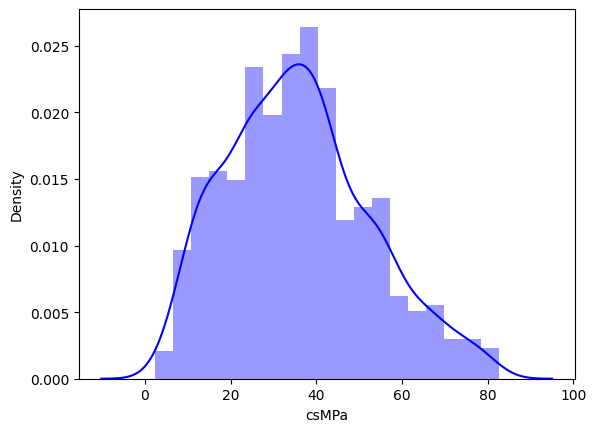

In [ ]:
#checking thedistribution of the concrete compressive test
sns.distplot(cement_data['csMPa'],color='blue')

In [ ]:
X=cement_data.drop('csMPa',axis=1)
Y=cement_data['csMPa']

In [ ]:
print(X)

      cement   slag  flyash  water  superplasticizer  coarseaggregate  \
0      540.0    0.0     0.0  162.0               2.5           1040.0   
1      540.0    0.0     0.0  162.0               2.5           1055.0   
2      332.5  142.5     0.0  228.0               0.0            932.0   
3      332.5  142.5     0.0  228.0               0.0            932.0   
4      198.6  132.4     0.0  192.0               0.0            978.4   
...      ...    ...     ...    ...               ...              ...   
1025   276.4  116.0    90.3  179.6               8.9            870.1   
1026   322.2    0.0   115.6  196.0              10.4            817.9   
1027   148.5  139.4   108.6  192.7               6.1            892.4   
1028   159.1  186.7     0.0  175.6              11.3            989.6   
1029   260.9  100.5    78.3  200.6               8.6            864.5   

      fineaggregate  age  
0             676.0   28  
1             676.0   28  
2             594.0  270  
3             5

In [ ]:
print(Y)

0       79.99
1       61.89
2       40.27
3       41.05
4       44.30
        ...  
1025    44.28
1026    31.18
1027    23.70
1028    32.77
1029    32.40
Name: csMPa, Length: 1030, dtype: float64


In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [ ]:
regressor=RandomForestRegressor(n_estimators=100)

In [ ]:
#training the model
regressor.fit(X_train,Y_train)
RandomForestRegressor()



RandomForestRegressor()

In [ ]:
#prediction on TrainingData
train_data_prediction=regressor.predict(X_train)
#R squared error
error_score=metrics.r2_score(Y_train,train_data_prediction)
print('R squared error:',error_score)

R squared error: 0.9852504917073018


In [ ]:
#prediction on TestData
test_data_prediction=regressor.predict(X_test)
#R squared error
error_score=metrics.r2_score(Y_test,test_data_prediction)
print('R squared error:',error_score)


R squared error: 0.8942129241897728


In [ ]:
Y_test=list(Y_test)

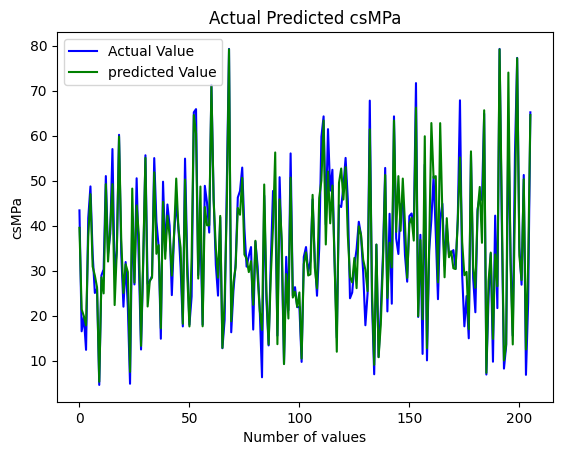

In [ ]:
plt.plot(Y_test,color='blue',label='Actual Value')
plt.plot(test_data_prediction,color='green',label='predicted Value')
plt.title('Actual Predicted csMPa')
plt.xlabel('Number of values')
plt.ylabel('csMPa')
plt.legend()
plt.show()